检验机器学习模型
流程：
1. FVCOM和SWAN计算结果，通过matlab程序“main_prepare_test_case.mlx”准备Environment_testcast.mat文件
- 文件包含风、潮、流、浪
- 变量中nan均替换成了0
2. 通过本程序加载mat数据，整理数据并用于预测
3. 加载**工作站**中训练好的模型，进行数据预测
4. 将预测结果与计算结果进行对比

# 加载数据

## 加载mat数据

In [ ]:
# 加载mat数据
import scipy.io
import numpy as np
import os
import h5py # <-- 引入 h5py 库
from typing import Union, Dict, Any, Optional

def load_mat_variable(
    file_path: str, 
    variable_name: str
    ) -> Optional[np.ndarray]: # 简化返回类型提示，因为h5py通常返回ndarray
    """
    Load a specific variable from a MATLAB .mat file. 
    It attempts to use h5py for v7.3 files and scipy.io.loadmat for older files.

    Args:
        file_path (str): The full path to the .mat file.
        variable_name (str): The name of the variable to load.

    Returns:
        Optional[np.ndarray]: The data of the specified variable as a NumPy array, 
        or None if loading fails or the variable is not found.
    """
    # 1. 检查文件是否存在
    if not os.path.exists(file_path):
        print(f"Error: File not found at '{file_path}'")
        return None

    # --- 尝试使用 h5py 读取 (针对 v7.3 文件) ---
    try:
        with h5py.File(file_path, 'r') as f:
            if variable_name in f:
                # h5py 返回一个 HDF5 数据集 (Dataset)，需要将其读入内存并转置 (MATLAB默认列优先)
                data = f[variable_name][()] 
                
                # h5py读取的数组可能需要转置，特别是对于二维及以上的数据，以匹配通常的Python/NumPy习惯。
                # 由于MATLAB是列优先，SciPy会处理；但h5py不会自动处理。
                # 经验上，对于非向量数据，通常需要转置。
                if data.ndim > 1:
                     data = data.T
                
                print(f"Successfully loaded '{variable_name}' (v7.3 HDF5) from '{file_path}'.")
                print(f"Data shape: {data.shape}")
                
                # 如果是 MATLAB 结构体，数据可能会以 HDF5 引用形式存在，处理会更复杂，
                # 但对于 'Wind' 这种常见的数值矩阵，上述代码通常足够。
                return data
            else:
                available_vars = list(f.keys())
                print(f"Error: Variable '{variable_name}' not found in the .mat file (v7.3 format).")
                print(f"Available variables: {available_vars}")
                return None
                
    except ImportError:
        print("Warning: h5py is not installed. Trying scipy.io.loadmat...")
        pass # 如果 h5py 未安装，则继续尝试 SciPy
        
    except Exception as e:
        # 如果 h5py 失败，可能是因为它不是 v7.3 文件，或者是文件损坏
        if "h5py" not in str(e): # 排除 h5py 自身的导入错误
             print(f"H5PY failed with error: {e}. Trying scipy.io.loadmat...")
        pass 
    
    # --- 尝试使用 scipy.io.loadmat 读取 (针对 v7.2 及更早版本) ---
    try:
        mat_contents = scipy.io.loadmat(file_path)
        
        if variable_name in mat_contents:
            data = mat_contents[variable_name]
            print(f"Successfully loaded '{variable_name}' (old format) from '{file_path}'.")
            
            if isinstance(data, np.ndarray):
                print(f"Data shape: {data.shape}")
                
            return data
        else:
            available_vars = [k for k in mat_contents.keys() if not k.startswith('__')]
            print(f"Error: Variable '{variable_name}' not found in the .mat file.")
            print(f"Available variables (excluding metadata): {available_vars}")
            return None

    except Exception as e:
        # 如果 SciPy 也失败了，说明文件可能损坏或路径有问题
        print(f"An error occurred while loading the file '{file_path}' using scipy: {e}")
        return None


# --- 示例调用 ---
tc_id = 202203 # 201623 Sarika; 201723 Khanun; 202203 Chaba; 202412 yagi
file_path = f"G:/20251014PINN/datas/Environment_{tc_id}.mat" 
variable_name = 'Wave' 
case_instance = 60 # 100 & 130 - 201623 Sarika; 100 & 110 - 201723 Khanun; 60 & 150 - 202203 Chaba; 120 & 130 - 202412 yagi

wind_data_mat = load_mat_variable(file_path, 'Wind')

test_data_mat = load_mat_variable(file_path, 'Wave_compute')

era5_data_mat = load_mat_variable(file_path, 'Wave_era5')

Successfully loaded 'Wind' (v7.3 HDF5) from 'G:/20251014PINN/datas/Environment_201623.mat'.
Data shape: (180, 4096)
Successfully loaded 'Wave_compute' (v7.3 HDF5) from 'G:/20251014PINN/datas/Environment_201623.mat'.
Data shape: (180, 4096)
Successfully loaded 'Wave_era5' (v7.3 HDF5) from 'G:/20251014PINN/datas/Environment_201623.mat'.
Data shape: (180, 4096)


## 数据整理

In [106]:
import gc

# 研究区域坐标
'''x = np.linspace(105.3, 116.0, 64, dtype=float)
y = np.linspace(12.0, 23.0, 64, dtype=float)'''
x = np.linspace(110.5, 113.5, 64, dtype = float)
y = np.linspace(17.5, 20.5, 64, dtype = float)
X,Y = np.meshgrid(x, y)

# 将wind_data_mat进行转化
N, S = wind_data_mat.shape  # N时间步长，S空间点数(64*64=4096)
wind_2d = wind_data_mat.reshape(N, 64, 64).transpose(0, 2, 1)  # (N, 64, 64)

# 将wind_2d进行堆叠
wind_real = wind_2d['real'].astype(np.float32)  # (*, 64, 64)
wind_imag = wind_2d['imag'].astype(np.float32)  # 同上
wind_combined = np.stack([wind_real, wind_imag], axis=1)  # (*, 2, 64, 64)
wind_combined = wind_combined[case_instance-1, :, :, :].reshape(1, 2, 64, 64)

print("Wind combined shape:", wind_combined.shape)


# 将test_data_mat进行转化
if variable_name.lower() == 'wave':
    data_2d = test_data_mat.reshape(N, 64, 64).transpose(0, 2, 1)
    true_2d = data_2d[case_instance - 1, :, :].astype(np.float32)  # (64, 64)
    print(f"{variable_name} shape:", true_2d.shape)

    data_2d = era5_data_mat.reshape(N, 64, 64).transpose(0, 2, 1)
    era5_2d = data_2d[case_instance - 1, :, :].astype(np.float32)  # (64, 64)
    print(f"ERA5 shape:", era5_2d.shape)

Wind combined shape: (1, 2, 64, 64)
Wave shape: (64, 64)
ERA5 shape: (64, 64)


## 将数据归一化

In [107]:
import joblib
import numpy as np

scaler_wind = joblib.load('../datas/scaler_wind.joblib')
scaler_output = joblib.load(f'../datas/scaler_{variable_name.lower()}.joblib')
print("Scaler wind n_features_in_:", scaler_wind.n_features_in_)
print("Scaler output n_features_in_:", scaler_output.n_features_in_)

# 全局归一化：风速
wind_sample_reshaped = wind_combined.reshape(1, -1)  # (1, C*H*W)
wind_sample_norm_flat = scaler_wind.transform(wind_sample_reshaped)
wind_normalized = wind_sample_norm_flat.reshape(1, 2, 64, 64)
# 将wind_combined和true_2d进行归一化
'''wind_sample_reshaped = wind_combined.reshape(1, 2, 64, 64).transpose(0, 2, 3, 1).reshape(-1, 2)
wind_sample_norm_flat = scaler_wind.transform(wind_sample_reshaped)
wind_normalized = wind_sample_norm_flat.reshape(1, 64, 64, 2).transpose(0, 3, 1, 2)'''

# 立即删除大数组
del wind_sample_reshaped, wind_sample_norm_flat
gc.collect()

# 输出变量归一化
# Surge / Wave 是 1 通道 (1, 64, 64) -> (1*64*64, 1)
output_flat = true_2d.reshape(1, -1)
# output_flat = true_2d.reshape(-1, 1)

out_normalized_flat = scaler_output.transform(output_flat)
output_normalized = out_normalized_flat.reshape(true_2d.shape)

# 立即释放内存
del output_flat, out_normalized_flat
gc.collect()

# 验证非 NaN
print(f"Normalized wind NaN: {np.any(np.isnan(wind_normalized))}")
print(f"Normalized output NaN: {np.any(np.isnan(output_normalized))}")
print(f"Wind normalized min/max: {np.nanmin(wind_normalized):.2f} / {np.nanmax(wind_normalized):.2f}")
print(f"Output normalized min/max: {np.nanmin(output_normalized):.2f} / {np.nanmax(output_normalized):.2f}")

Scaler wind n_features_in_: 8192
Scaler output n_features_in_: 4096
Normalized wind NaN: False
Normalized output NaN: True
Wind normalized min/max: -1.05 / 0.97
Output normalized min/max: 0.10 / 5.18


绘制风速和变量的空间地图

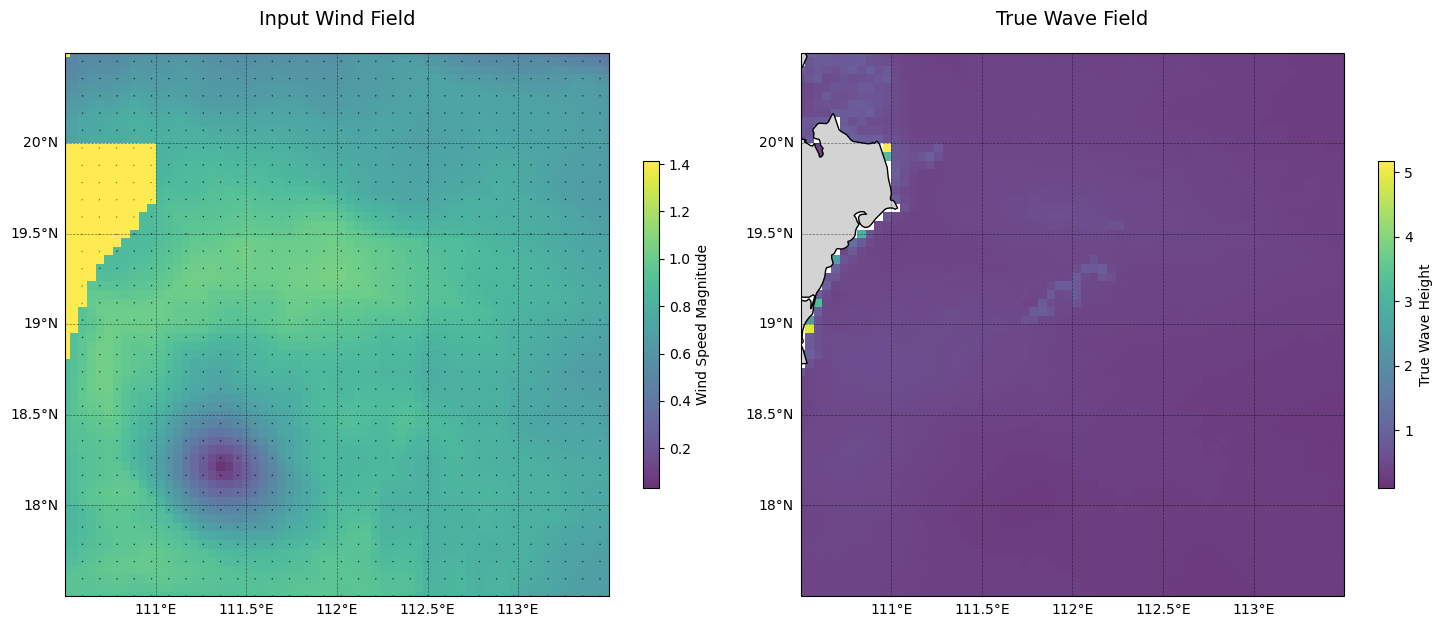

In [108]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter

# Define formatters if not already
LONGITUDE_FORMATTER = LongitudeFormatter()
LATITUDE_FORMATTER = LatitudeFormatter()

# Create subplots with shared projection
fig = plt.figure(figsize=(15, 6))
ax1 = plt.subplot(1, 2, 1, projection=ccrs.PlateCarree())
ax2 = plt.subplot(1, 2, 2, projection=ccrs.PlateCarree())

# Common extent
extent = [np.min(x), np.max(x), np.min(y), np.max(y)]

# Wind field subplot (ax1)
ax1.set_extent(extent, crs=ccrs.PlateCarree())

# Compute magnitude if not already
wind_inversed = scaler_wind.inverse_transform(wind_normalized.reshape(1, -1)).reshape(1, 2, 64, 64)
wind_field_np = np.sqrt(wind_normalized[0, 0, :, :]**2 + wind_normalized[0, 1, :, :]**2)
'''wind_field_np = np.sqrt(wind_combined[0,:]**2 + wind_combined[1,:]**2)'''

# pcolormesh for magnitude
im1 = ax1.pcolormesh(X, Y, wind_field_np, cmap='viridis', transform=ccrs.PlateCarree(), alpha=0.8, shading='auto', zorder=1)
plt.colorbar(im1, ax=ax1, label='Wind Speed Magnitude', shrink=0.6)
# set the colorbar range
# im1.set_clim(0,1)

# Quiver for wind vectors (subsample to avoid overcrowding, e.g., every 2nd point; adjust as needed)
# 将quiver的箭头长度均设置成1
skip = 2  # Adjust skip based on grid resolution
Xq = X[::skip, ::skip]
Yq = Y[::skip, ::skip]
Uq = wind_normalized[0, 0, ::skip, ::skip]
Vq = wind_normalized[0, 1, ::skip, ::skip]
'''Uq = wind_combined[0, ::skip, ::skip]
Vq = wind_combined[1, ::skip, ::skip]'''
ax1.quiver(Xq, Yq, Uq, Vq, transform=ccrs.PlateCarree(), scale=400, width=0.003, color='black', alpha=0.7, zorder=2)  # Adjust scale as needed
# Add land and features
# ax1.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black', zorder=2)

# Gridlines
gl1 = ax1.gridlines(draw_labels=True, linewidth=0.5, color='black', alpha=0.5, linestyle='--', zorder=5)
gl1.top_labels = False
gl1.right_labels = False
gl1.xlabels_top = False
gl1.ylabels_right = False
gl1.xformatter = LONGITUDE_FORMATTER
gl1.yformatter = LATITUDE_FORMATTER

ax1.set_title('Input Wind Field', fontsize=14, pad=20)

# Predicted wave field subplot (ax2)
ax2.set_extent(extent, crs=ccrs.PlateCarree())

# pcolormesh for wave height
im2 = ax2.pcolormesh(X, Y, output_normalized, cmap='viridis', transform=ccrs.PlateCarree(), alpha=0.8, shading='auto', zorder=1)
plt.colorbar(im2, ax=ax2, label=f'True {variable_name.capitalize()} Height', shrink=0.6)

# Add land and features
ax2.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black', zorder=2)

# Gridlines
gl2 = ax2.gridlines(draw_labels=True, linewidth=0.5, color='black', alpha=0.5, linestyle='--')
gl2.top_labels = False
gl2.right_labels = False
gl2.xlabels_top = False
gl2.ylabels_right = False
gl2.xformatter = LONGITUDE_FORMATTER
gl2.yformatter = LATITUDE_FORMATTER

ax2.set_title(f'True {variable_name.capitalize()} Field', fontsize=14, pad=20)

plt.tight_layout()
plt.show()

# 加载模型

In [109]:
import torch
# 关键步骤：导入类定义
from f_model_defination import UNetBoosting, XGBoostUNet, UNet

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 1. 实例化结构 (参数必须与训练时一致)
model_type = 'XGBoostUNet'  # 可选'XGBoostUNet' 或 'UNet'

if model_type == 'XGBoostUNet':
    '''boosting_model = UNetBoosting(num_models=5, in_channels=2, out_channels=1, learning_rate=1e-3, 
        shrinkage=0.6, features=[32, 64, 128, 256, 512],device=device, env_type=variable_name.lower()
    ).to(device)'''
                                                                    
    # 创建 XGBoostUNet 实例
    boosting_model = XGBoostUNet(
        num_models=8,          # 弱学习器的数量
        learning_rate=4e-3,   # 学习率(默认1e-3)
        shrinkage=0.5,         # 子模型收缩率
        subsample=0.8,         # 样本采样比例
        reg_lambda=1e-4,       # L2 正则化
        features=[16, 32, 64, 128],
        env_type='wave',       # 根据环境类型自动选择梯度计算方式
        device=device
    )

    # XGBoostUNet 权重加载
    boosting_model.load_state_dict(torch.load(f'../datas/optim_xgboosting_unet_{variable_name.lower()}_model_v6.3.pth', map_location=device))

else:

    boosting_model = UNet(
        in_channels=2,
        out_channels=1,
        features=[16, 32, 64, 128],
        env_type=variable_name.lower()
    ).to(device)

    # UNet 权重加载
    boosting_model.load_state_dict(torch.load(f'G:/20251014PINN/datas/unet_{variable_name.lower()}_model_v3.5.0_small_region.pth', map_location=device))


'''boosting_model.load_state_dict(
    torch.load(f'../datas/unet_boosting_{variable_name.lower()}_model_v5.7.pth', map_location=device)
)'''


"boosting_model.load_state_dict(\n    torch.load(f'../datas/unet_boosting_{variable_name.lower()}_model_v5.7.pth', map_location=device)\n)"

# 预报

In [110]:
import torch

# 准备输入张量
wind_tensor = torch.from_numpy(wind_normalized).float().to(device)
# wind_tensor = wind_tensor.unsqueeze(0)  # 添加批次维度，变为 (1, 2, 56, 54)

# 模型推理
boosting_model.eval()
with torch.no_grad():
    env_pred_normalized = boosting_model(wind_tensor)
    env_pred_normalized_np = env_pred_normalized.squeeze().cpu().numpy()  # (56, 54)
print("Predicted normalized shape:", env_pred_normalized_np.shape)


# 反归一化
env_pred_flat = env_pred_normalized_np.reshape(1, -1)  # (1, 56*54)
env_pred_np = scaler_output.inverse_transform(env_pred_flat).reshape(64, 64)  # (64, 64)


print("True max value (normalized):", np.max(output_normalized))
print("Predicted max value (normalized):", np.max(env_pred_normalized_np))
print(f"True max value: {np.max(true_2d):.2f}")
print(f"Predicted max value: {np.max(env_pred_np):.2f}")
print(f"ERA5 max value: {np.max(era5_2d):.2f}")

Predicted normalized shape: (64, 64)
True max value (normalized): nan
Predicted max value (normalized): 0.9663551
True max value: nan
Predicted max value: 14.31
ERA5 max value: 9.18


In [111]:
print("scaler_output.min_.shape:", scaler_output.min_.shape)
print("scaler_output.scale_.shape:", scaler_output.scale_.shape)
print("scaler_output.n_features_in_:", scaler_output.n_features_in_)

scaler_output.min_.shape: (4096,)
scaler_output.scale_.shape: (4096,)
scaler_output.n_features_in_: 4096


## 结果可视化

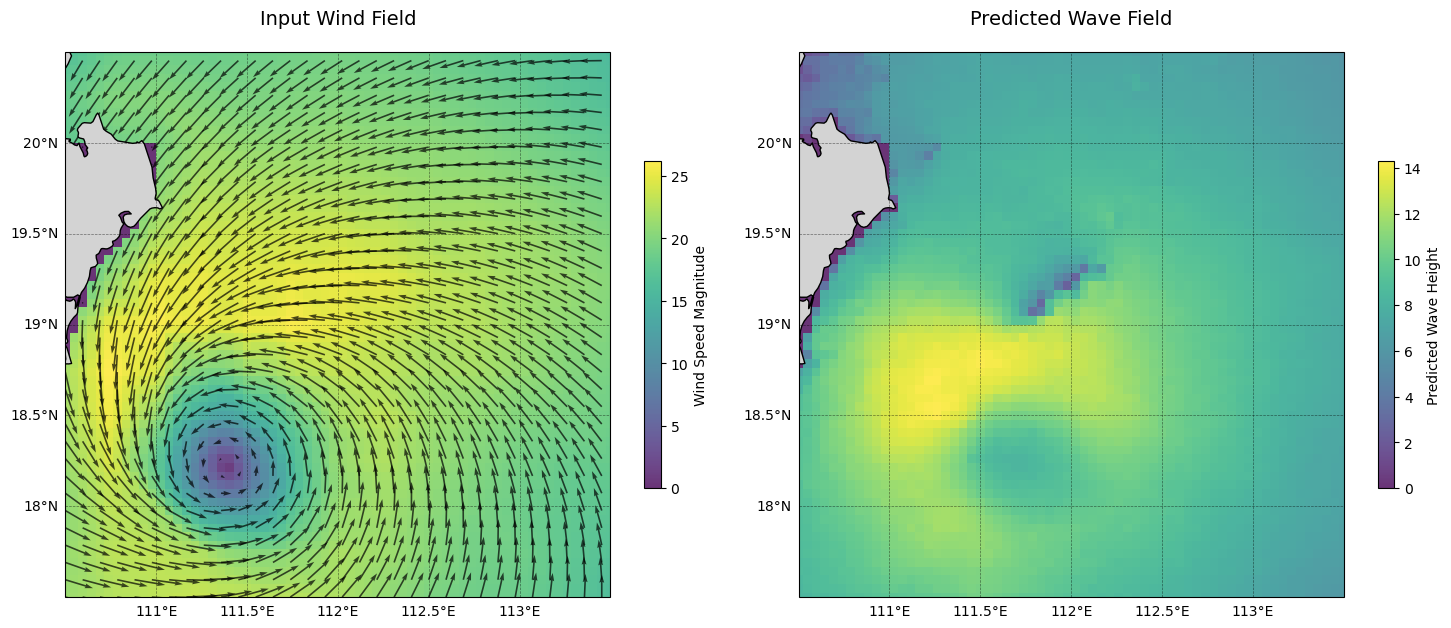

In [112]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter

# Define formatters if not already
LONGITUDE_FORMATTER = LongitudeFormatter()
LATITUDE_FORMATTER = LatitudeFormatter()

# Create subplots with shared projection
fig = plt.figure(figsize=(15, 6))
ax1 = plt.subplot(1, 2, 1, projection=ccrs.PlateCarree())
ax2 = plt.subplot(1, 2, 2, projection=ccrs.PlateCarree())

# Common extent
# extent = [105.3, 116.0, 12.0, 23.0]
extent = [np.min(x), np.max(x), np.min(y), np.max(y)]

# Wind field subplot (ax1)
ax1.set_extent(extent, crs=ccrs.PlateCarree())

# Compute magnitude if not already
wind_field_np = np.sqrt(wind_combined[0,0,:]**2 + wind_combined[0,1,:]**2)

# pcolormesh for magnitude
im1 = ax1.pcolormesh(X, Y, wind_field_np, cmap='viridis', transform=ccrs.PlateCarree(), alpha=0.8, shading='auto', zorder=1)
plt.colorbar(im1, ax=ax1, label='Wind Speed Magnitude', shrink=0.6)

# Quiver for wind vectors (subsample to avoid overcrowding, e.g., every 2nd point; adjust as needed)
# 将quiver的箭头长度均设置成1
skip = 2  # Adjust skip based on grid resolution
Xq = X[::skip, ::skip]
Yq = Y[::skip, ::skip]
Uq = wind_combined[0, 0, ::skip, ::skip]
Vq = wind_combined[0, 1, ::skip, ::skip]
ax1.quiver(Xq, Yq, Uq, Vq, transform=ccrs.PlateCarree(), scale=400, width=0.003, color='black', alpha=0.7, zorder=2)  # Adjust scale as needed
# Add land and features
ax1.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black', zorder=2)

# Gridlines
gl1 = ax1.gridlines(draw_labels=True, linewidth=0.5, color='black', alpha=0.5, linestyle='--', zorder=5)
gl1.top_labels = False
gl1.right_labels = False
gl1.xlabels_top = False
gl1.ylabels_right = False
gl1.xformatter = LONGITUDE_FORMATTER
gl1.yformatter = LATITUDE_FORMATTER

ax1.set_title('Input Wind Field', fontsize=14, pad=20)

# Predicted wave field subplot (ax2)
ax2.set_extent(extent, crs=ccrs.PlateCarree())

# pcolormesh for wave height
im2 = ax2.pcolormesh(X, Y, env_pred_np, cmap='viridis', transform=ccrs.PlateCarree(), alpha=0.8, shading='auto', zorder=1)
plt.colorbar(im2, ax=ax2, label=f'Predicted {variable_name.capitalize()} Height', shrink=0.6)

# Add land and features
ax2.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black', zorder=2)

# Gridlines
gl2 = ax2.gridlines(draw_labels=True, linewidth=0.5, color='black', alpha=0.5, linestyle='--')
gl2.top_labels = False
gl2.right_labels = False
gl2.xlabels_top = False
gl2.ylabels_right = False
gl2.xformatter = LONGITUDE_FORMATTER
gl2.yformatter = LATITUDE_FORMATTER

ax2.set_title(f'Predicted {variable_name.capitalize()} Field', fontsize=14, pad=20)

plt.tight_layout()
plt.show()

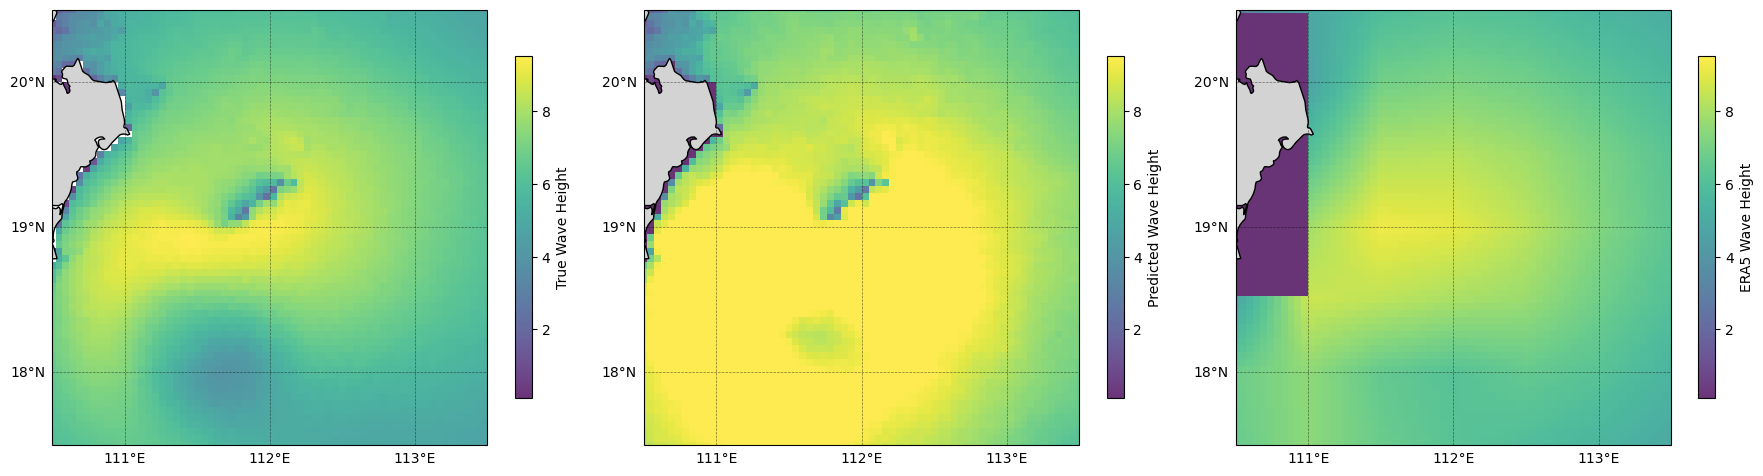

MSE: nan, MAE: nan
Correlation: nan
高值区 MAE: nan


d:\Softwares\Anaconda3\envs\cnn-model\lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
d:\Softwares\Anaconda3\envs\cnn-model\lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)


In [113]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
from mpl_toolkits.axes_grid1 import make_axes_locatable

# 定义格式器（如果之前代码中已定义，可忽略）
LONGITUDE_FORMATTER = LongitudeFormatter()
LATITUDE_FORMATTER = LatitudeFormatter()

# 对比图：预测 vs 真实（子图）
extent = [np.min(x), np.max(x), np.min(y), np.max(y)]

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, subplot_kw={'projection': ccrs.PlateCarree()}, figsize=(18, 6))

# ----------------------------真实场 ax1----------------------------
ax1.set_extent(extent, crs=ccrs.PlateCarree())
# pcolormesh for wave height
im_true = ax1.pcolormesh(X, Y, true_2d, cmap='viridis', transform=ccrs.PlateCarree(), alpha=0.8, shading='auto', zorder=1)
plt.colorbar(im_true, ax=ax1, orientation='vertical', label=f'True {variable_name.capitalize()} Height', shrink=0.6)
# ax1.set_title(f'True {variable_name.capitalize()} Field', fontsize=14, pad=20)
ax1.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black', zorder=2)
# 可选：为真实场也设置 clim（默认已匹配数据范围）
# im_true.set_clim(vmin=im_true.get_array().min(), vmax=im_true.get_array().max())
gl1 = ax1.gridlines(draw_labels=True, linewidth=0.5, color='black', alpha=0.5, linestyle='--')
gl1.top_labels = False
gl1.right_labels = False
gl1.xlabels_top = False
gl1.ylabels_right = False
gl1.xlocator = plt.FixedLocator(np.arange(105, 117, 1))
gl1.ylocator = plt.FixedLocator(np.arange(12, 24, 1))
gl1.xformatter = LONGITUDE_FORMATTER
gl1.yformatter = LATITUDE_FORMATTER

# ----------------------------预测场 ax2----------------------------
ax2.set_extent(extent, crs=ccrs.PlateCarree())
# pcolormesh for wave height
im_pred = ax2.pcolormesh(X, Y, env_pred_np, cmap='viridis', transform=ccrs.PlateCarree(), alpha=0.8, shading='auto', zorder=1)
# ax2.set_title(f'Predicted {variable_name.capitalize()} Field', fontsize=14, pad=20)
fig.colorbar(im_pred, ax=ax2, orientation='vertical', label=f'Predicted {variable_name.capitalize()} Height', shrink=0.6)
ax2.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black', zorder=2)
# 添加colorbar并设置范围，与真实场一致（在 im_pred 上调用 set_clim）
im_pred.set_clim(vmin=im_true.get_clim()[0], vmax=im_true.get_clim()[1])  # 修复：移到 im_pred 上
gl2 = ax2.gridlines(draw_labels=True, linewidth=0.5, color='black', alpha=0.5, linestyle='--')
gl2.top_labels = False
gl2.right_labels = False
gl2.xlabels_top = False
gl2.ylabels_right = False
gl2.xlocator = plt.FixedLocator(np.arange(105, 117, 1))
gl2.ylocator = plt.FixedLocator(np.arange(12, 24, 1))
gl2.xformatter = LONGITUDE_FORMATTER
gl2.yformatter = LATITUDE_FORMATTER

# ----------------------------ERA5 ax3----------------------------
ax3.set_extent(extent, crs=ccrs.PlateCarree())
# pcolormesh for wave height
im_era5 = ax3.pcolormesh(X, Y, era5_2d, cmap='viridis', transform=ccrs.PlateCarree(), alpha=0.8, shading='auto', zorder=1)
plt.colorbar(im_era5, ax=ax3, orientation='vertical', label=f'ERA5 {variable_name.capitalize()} Height', shrink=0.6)
# ax3.set_title(f'ERA5 {variable_name.capitalize()} Field', fontsize=14, pad=20)
ax3.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black', zorder=2)
# 可选：为真实场也设置 clim（默认已匹配数据范围）
im_era5.set_clim(vmin=im_true.get_clim()[0], vmax=im_true.get_clim()[1])  # 修复：移到 im_pred 上
gl3 = ax3.gridlines(draw_labels=True, linewidth=0.5, color='black', alpha=0.5, linestyle='--')
gl3.top_labels = False
gl3.right_labels = False
gl3.xlabels_top = False
gl3.ylabels_right = False
gl3.xlocator = plt.FixedLocator(np.arange(105, 117, 1))
gl3.ylocator = plt.FixedLocator(np.arange(12, 24, 1))
gl3.xformatter = LONGITUDE_FORMATTER
gl3.yformatter = LATITUDE_FORMATTER


# ----------------------------输出----------------------------
plt.tight_layout()
plt.show()

# 打印对比统计
mse = np.mean((env_pred_np - true_2d)**2)
mae = np.mean(np.abs(env_pred_np - true_2d))
correlation = np.corrcoef(env_pred_np.flatten(), true_2d.flatten())[0, 1]
print(f"MSE: {mse:.4f}, MAE: {mae:.4f}")
print(f"Correlation: {correlation:.4f}")

# 高值区域 MAE
high_region = true_2d > np.percentile(true_2d, 90)
print(f"高值区 MAE: {np.mean(np.abs(env_pred_np[high_region] - true_2d[high_region])):.4f}")

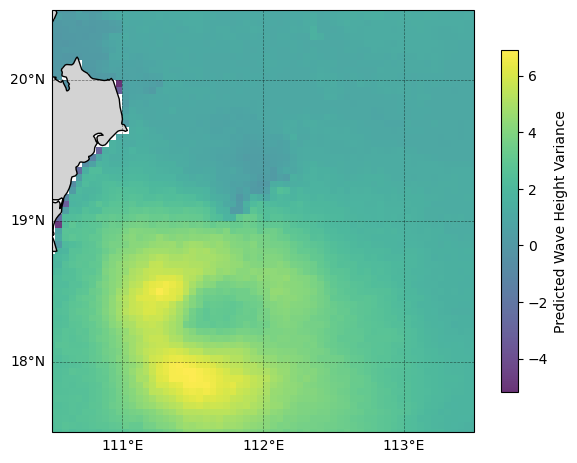

In [114]:
# 对比图：预测 vs 真实（子图）
extent = [np.min(x), np.max(x), np.min(y), np.max(y)]

fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()}, figsize=(6, 6))

# 真实场
ax.set_extent(extent, crs=ccrs.PlateCarree())
# pcolormesh for wave height
if variable_name.lower() == 'current':
    true_sample_abs = np.sqrt(true_2d[0]**2 + true_2d[1]**2)  # 计算流速幅值
    env_pred_np_abs = np.sqrt(env_pred_np[0]**2 + env_pred_np[1]**2)  # 计算流速幅值
    im_true = ax.pcolormesh(X, Y, env_pred_np_abs - true_sample_abs, cmap='viridis', transform=ccrs.PlateCarree(), alpha=0.8, shading='auto', zorder=1)
    plt.colorbar(im_true, ax=ax, orientation='vertical', label='Predicted Current Speed Variance', shrink=0.6)
else:
    im_true = ax.pcolormesh(X, Y, env_pred_np - true_2d, cmap='viridis', transform=ccrs.PlateCarree(), alpha=0.8, shading='auto', zorder=1)
    plt.colorbar(im_true, ax=ax, orientation='vertical', label=f'Predicted {variable_name.capitalize()} Height Variance', shrink=0.6)
ax.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black', zorder=2)
# 可选：为真实场也设置 clim（默认已匹配数据范围）
im_true.set_clim(vmin=im_true.get_array().min(), vmax=im_true.get_array().max())
gl1 = ax.gridlines(draw_labels=True, linewidth=0.5, color='black', alpha=0.5, linestyle='--')
gl1.top_labels = False
gl1.right_labels = False
gl1.xlabels_top = False
gl1.ylabels_right = False
gl1.xlocator = plt.FixedLocator(np.arange(105, 117, 1))
gl1.ylocator = plt.FixedLocator(np.arange(12, 24, 1))
gl1.xformatter = LONGITUDE_FORMATTER
gl1.yformatter = LATITUDE_FORMATTER

plt.tight_layout()
plt.show()